In [1]:
import xarray as xr
import xradar as xd
from io import BytesIO
from obstore.store import S3Store

In [2]:
bucket = "s3://fmi-opendata-radar-volume-hdf5/"
store = S3Store.from_url(
    bucket, 
    skip_signature=True,
    region="eu-west-1",
)

In [3]:
async def list_raw_objects(path)-> list[str]:
    paths: list[str] = []
    async for batch in store.list(path):
        for obj in batch:
            paths.append(obj["path"])
    return paths

def get_geocoords(ds)-> xr.Dataset:
    """
    Converts Cartesian coordinates (x, y, z) in a radar dataset to geographic
    coordinates (longitude, latitude, altitude) using CRS transformation.

    Parameters
    ----------
    ds : xarray.Dataset
        Radar dataset with Cartesian coordinates.

    Returns
    -------
    xarray.Dataset
        Dataset with added 'lon', 'lat', and 'alt' coordinates and their attributes.
    """
    from pyproj import CRS, Transformer

    # Convert the dataset to georeferenced coordinates
    ds = ds.xradar.georeference()
    # Define source and target coordinate reference systems (CRS)
    src_crs = ds.xradar.get_crs()
    trg_crs = CRS.from_user_input(4326)  # EPSG:4326 (WGS 84)
    # Create a transformer for coordinate conversion
    transformer = Transformer.from_crs(src_crs, trg_crs)
    # Transform x, y, z coordinates to latitude, longitude, and altitude
    trg_y, trg_x, trg_z = transformer.transform(ds.x, ds.y, ds.z)
    # Assign new coordinates with appropriate attributes
    ds = ds.assign_coords(
        {
            "lon": (ds.x.dims, trg_x, xd.model.get_longitude_attrs()),
            "lat": (ds.y.dims, trg_y, xd.model.get_latitude_attrs()),
            "alt": (ds.z.dims, trg_z, xd.model.get_altitude_attrs()),
        }
    )
    return ds

In [4]:
paths = await list_raw_objects("2025/05/29/fivim/")

In [5]:
paths[0]

'2025/05/29/fivim/202505290000_fivim_PVOL.h5'

In [6]:
result = store.get(paths[0])

In [7]:
dt_car = xd.io.open_odim_datatree(BytesIO(result.bytes()),
        chunks={"azimuth": 360, "range": 497}
    ).xradar.map_over_sweeps(get_geocoords)

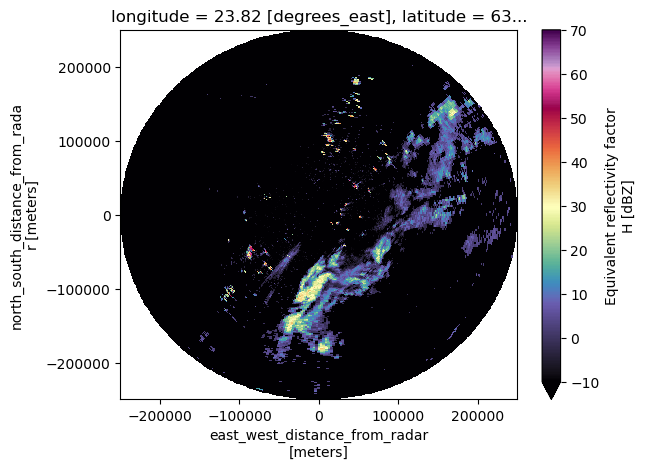

In [8]:
dt_car["sweep_0/DBZH"].plot(
    x="x", 
    y="y",
    vmin=-10, vmax=70, cmap="ChaseSpectral")

In [9]:
dt_car["sweep_0/DBZH"]

<xarray.DataArray 'DBZH' (azimuth: 360, range: 500)> Size: 1MB
dask.array<open_dataset-DBZH, shape=(360, 500), dtype=float64, chunksize=(360, 497), chunktype=numpy.ndarray>
Coordinates: (12/14)
    elevation  (azimuth) float64 3kB dask.array<chunksize=(360,), meta=np.ndarray>
    time       (azimuth) datetime64[ns] 3kB dask.array<chunksize=(360,), meta=np.ndarray>
  * range      (range) float32 2kB 250.0 750.0 1.25e+03 ... 2.492e+05 2.498e+05
    longitude  float64 8B ...
    latitude   float64 8B ...
    altitude   float64 8B ...
    ...         ...
    x          (azimuth, range) float64 1MB dask.array<chunksize=(360, 500), meta=np.ndarray>
    y          (azimuth, range) float64 1MB dask.array<chunksize=(360, 500), meta=np.ndarray>
    z          (azimuth, range) float64 1MB dask.array<chunksize=(360, 500), meta=np.ndarray>
    lon        (azimuth, range) float64 1MB 23.82 23.82 23.82 ... 23.73 23.73
    lat        (azimuth, range) float64 1MB 63.11 63.11 63.12 ... 65.34 65.34
    alt        (azimuth, range) float64 1MB 201.3 204.0 ... 5.166e+03 5.183e+03
Attributes:
    _Undetect:      0.0
    units:          dBZ
    long_name:      Equivalent reflectivity factor H
    standard_name:  radar_equivalent_reflectivity_factor_h

In [10]:
result1 = store.get(paths[2])

In [11]:
ds = xr.open_dataset(
    BytesIO(result1.bytes()),
    engine="odim",
    group="sweep_0", 
    first_dim="time"
).pipe(get_geocoords)

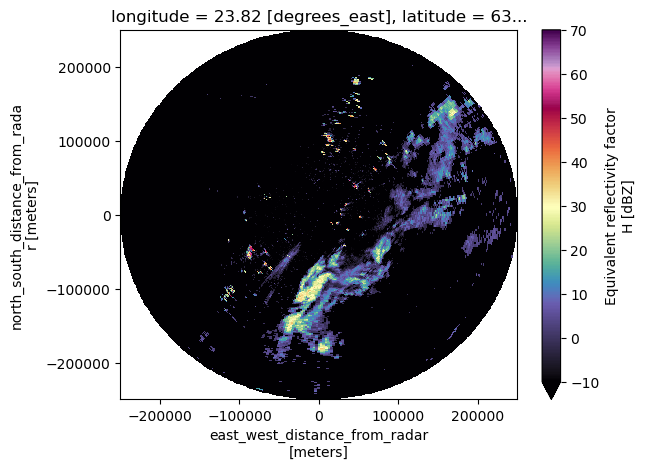

In [12]:
dt_car["sweep_0/DBZH"].plot(
    x="x", 
    y="y",
    vmin=-10, vmax=70, cmap="ChaseSpectral")